# Banking Term Deposit Prediction - Complete Analysis
## Predicting Customer Subscription to Term Deposits

**Author:** Atharva Khot  
**Date:** February 2026  
**Objective:** Develop a machine learning model to predict whether a customer will subscribe to a term deposit based on demographic, financial, and campaign-related attributes.

---

## 2. Import Libraries

In [1]:
# Data manipulation
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning - Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Machine Learning - Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, auc
)

# Handle Class Imbalance
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

## 3. Data Loading & Initial Exploration

In [2]:
# Load the dataset
df = pd.read_excel("Banking_Call_Data.xlsx")
# Display first few rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
# Shape of the Data
df.shape

(45211, 17)

In [4]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [5]:
# Statistical summary
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [6]:
# Detailed summary including categorical variables
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


## 4. Data Quality Checks

In [7]:
# Check for missing values
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [8]:
# Check for duplicate rows
df.duplicated().sum()

0

## 5. Exploratory Data Analysis (EDA)

### 5.1 Target Variable Analysis - **CRITICAL: Class Imbalance**

In [9]:
# Target variable distribution
print("Target Variable Distribution:") 
print(df['y'].value_counts())
print("\nPercentage Distribution:")
print(df['y'].value_counts(normalize=True) * 100)

# Calculate imbalance ratio
imbalance_ratio = df['y'].value_counts()['no'] / df['y'].value_counts()['yes']
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")
print(f"Only {(df['y'].value_counts()['yes']/len(df))*100:.2f}% of customers subscribed to term deposits.")

Target Variable Distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Percentage Distribution:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

Imbalance Ratio: 7.55:1
Only 11.70% of customers subscribed to term deposits.


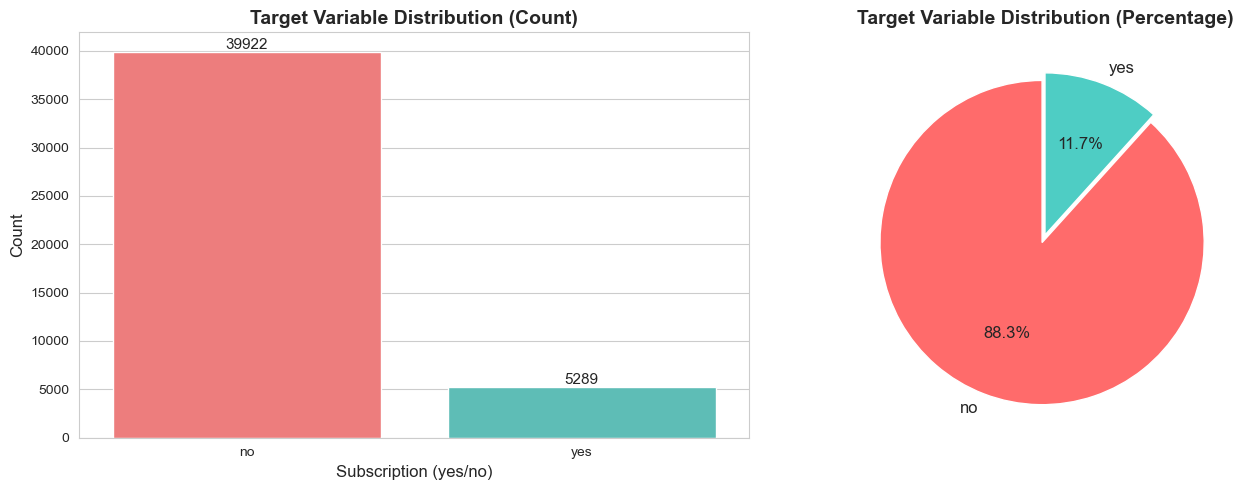

In [10]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(x='y', data=df, palette=['#FF6B6B', '#4ECDC4'], ax=axes[0])
axes[0].set_title('Target Variable Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Subscription (yes/no)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# Add count labels on bars
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=11)

# Pie chart
colors = ['#FF6B6B', '#4ECDC4']
explode = (0.05, 0)
df['y'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=explode,
    ax=axes[1],
    textprops={'fontsize': 12}
)
axes[1].set_title('Target Variable Distribution (Percentage)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 5.2 Demographic Features Analysis

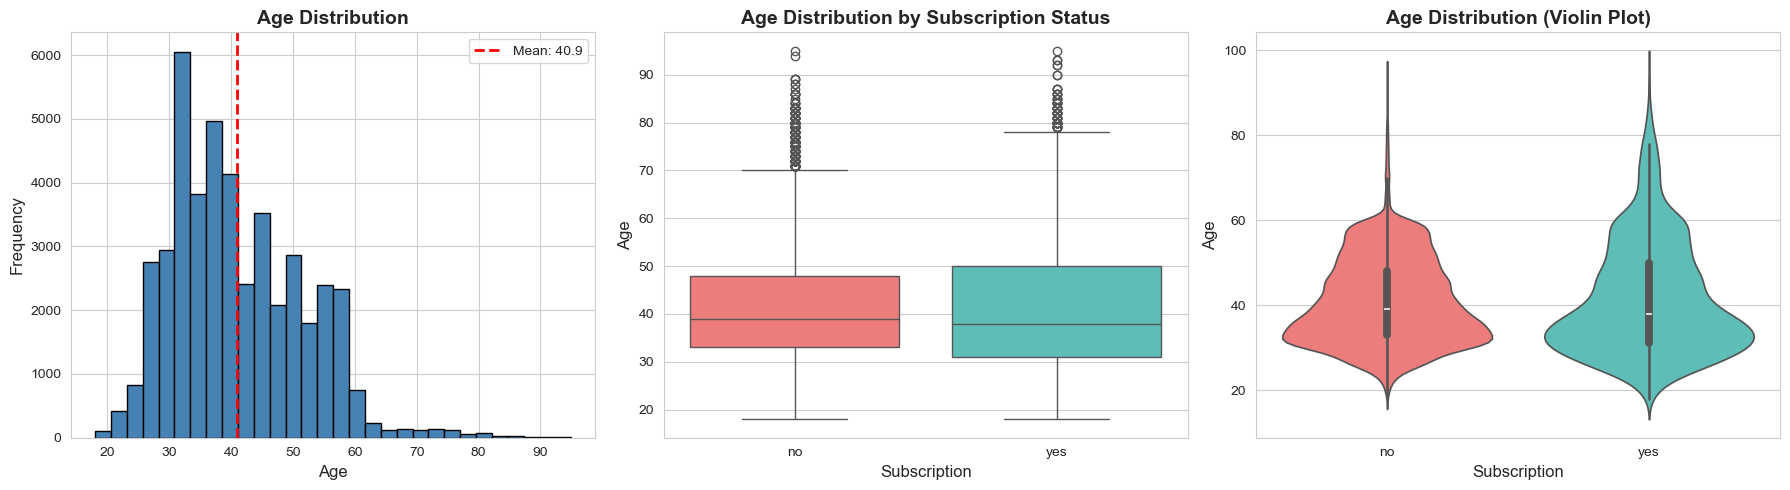

Age Statistics by Subscription:
       count       mean        std   min   25%   50%   75%   max
y                                                               
no   39922.0  40.838986  10.172662  18.0  33.0  39.0  48.0  95.0
yes   5289.0  41.670070  13.497781  18.0  31.0  38.0  50.0  95.0


In [11]:
# Age distribution analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age distribution
df['age'].hist(bins=30, edgecolor='black', ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["age"].mean():.1f}')
axes[0].legend()

# Age vs Target
sns.boxplot(x='y', y='age', data=df, palette=['#FF6B6B', '#4ECDC4'], ax=axes[1])
axes[1].set_title('Age Distribution by Subscription Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Subscription', fontsize=12)
axes[1].set_ylabel('Age', fontsize=12)

# Age violin plot
sns.violinplot(x='y', y='age', data=df, palette=['#FF6B6B', '#4ECDC4'], ax=axes[2])
axes[2].set_title('Age Distribution (Violin Plot)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Subscription', fontsize=12)
axes[2].set_ylabel('Age', fontsize=12)

plt.tight_layout()
plt.show()

# Statistical comparison
print("Age Statistics by Subscription:")
print("="*50)
print(df.groupby('y')['age'].describe())

<Figure size 1400x600 with 0 Axes>

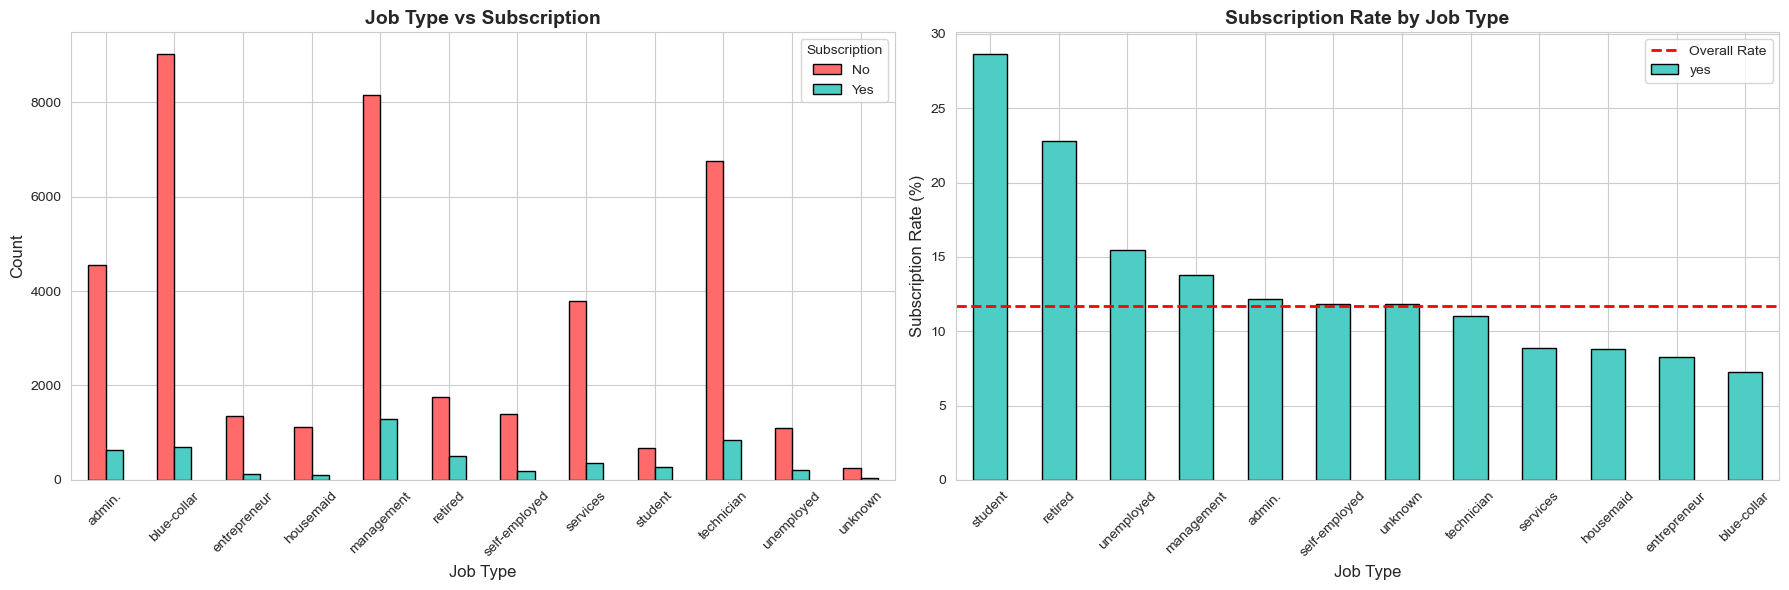


Subscription Rate by Job Type:
job
student          28.678038
retired          22.791519
unemployed       15.502686
management       13.755551
admin.           12.202669
self-employed    11.842939
unknown          11.805556
technician       11.056996
services          8.883004
housemaid         8.790323
entrepreneur      8.271688
blue-collar       7.274969
Name: yes, dtype: float64


In [12]:
# Job type analysis
plt.figure(figsize=(14, 6))

# Calculate subscription rate by job
job_analysis = pd.crosstab(df['job'], df['y'], normalize='index') * 100
job_counts = df['job'].value_counts()

# Create subplot
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Job distribution with subscription
job_sub = pd.crosstab(df['job'], df['y'])
job_sub.plot(kind='bar', stacked=False, ax=axes[0], color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[0].set_title('Job Type vs Subscription', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Job Type', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].legend(['No', 'Yes'], title='Subscription')
axes[0].tick_params(axis='x', rotation=45)

# Subscription rate by job
job_analysis['yes'].sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='#4ECDC4', edgecolor='black')
axes[1].set_title('Subscription Rate by Job Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Job Type', fontsize=12)
axes[1].set_ylabel('Subscription Rate (%)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=11.7, color='red', linestyle='--', linewidth=2, label='Overall Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nSubscription Rate by Job Type:")
print("="*50)
print(job_analysis['yes'].sort_values(ascending=False))

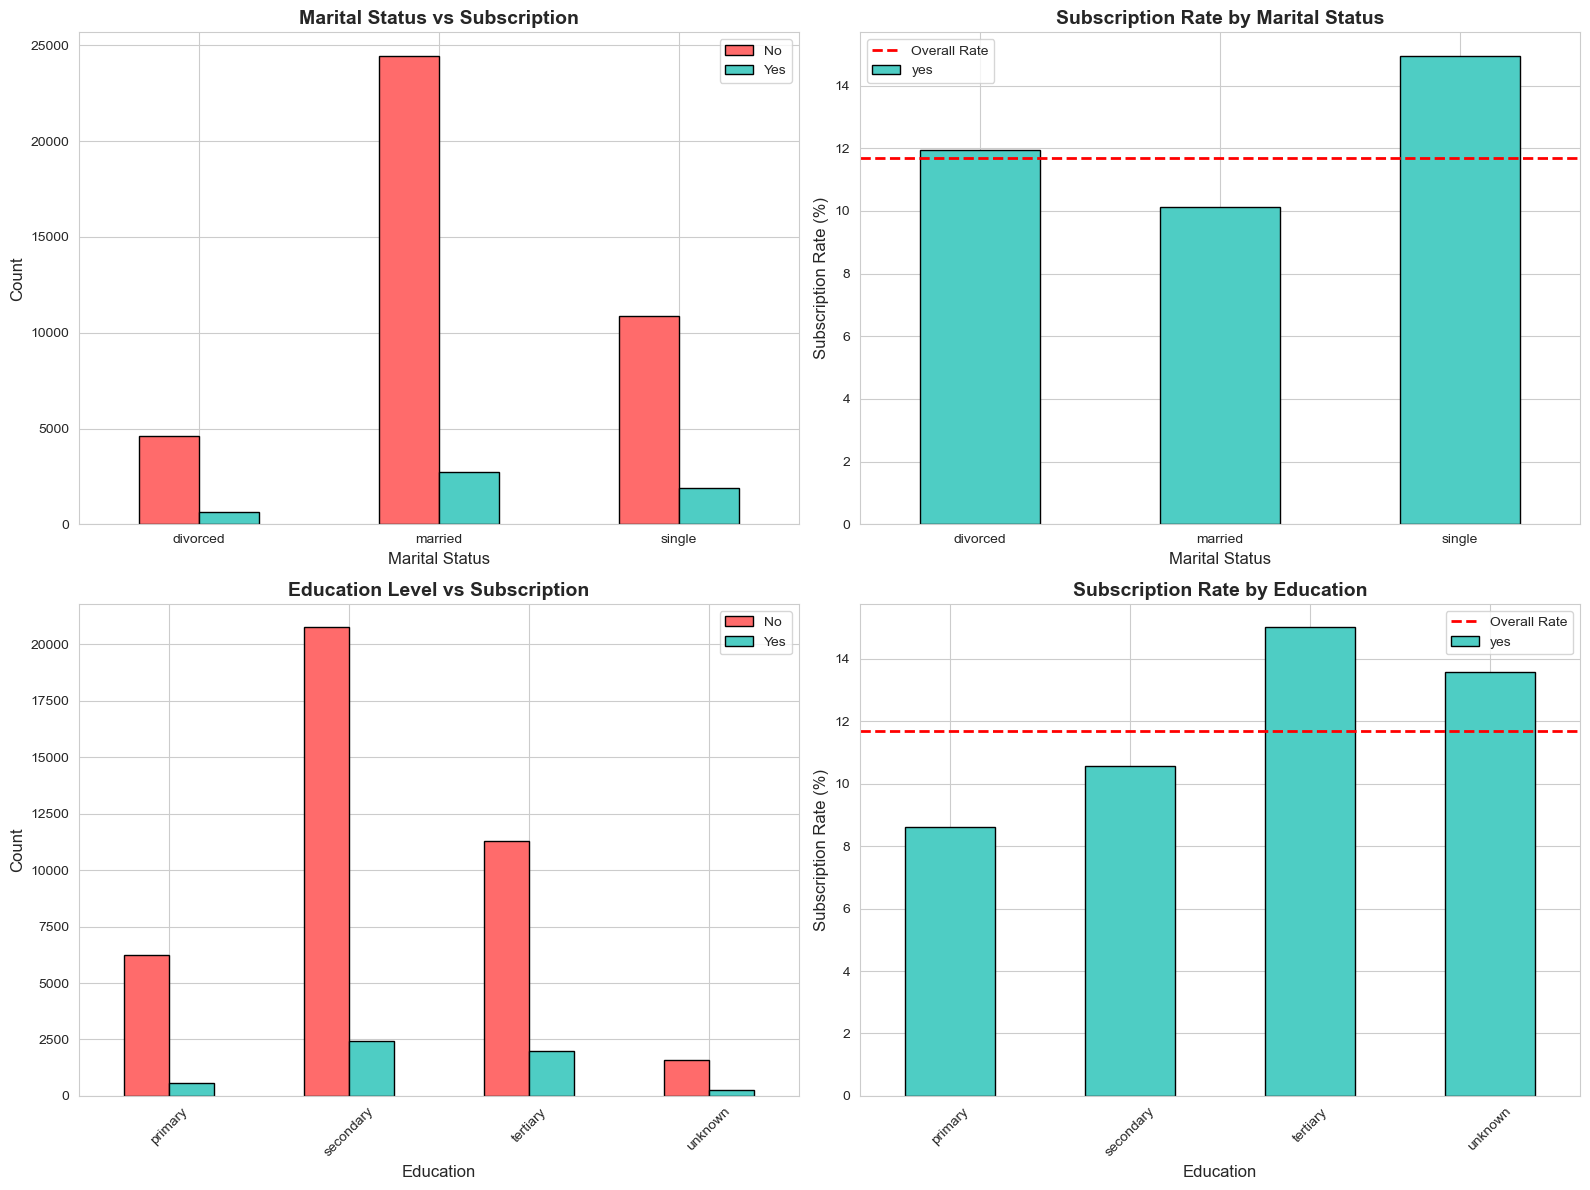

Subscription Rate by Marital Status:
marital
single      14.949179
divorced    11.945458
married     10.123466
Name: yes, dtype: float64

Subscription Rate by Education:
education
tertiary     15.006390
unknown      13.570275
secondary    10.559435
primary       8.626478
Name: yes, dtype: float64


In [13]:
# Marital status and Education analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Marital status
marital_sub = pd.crosstab(df['marital'], df['y'])
marital_sub.plot(kind='bar', ax=axes[0, 0], color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[0, 0].set_title('Marital Status vs Subscription', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Marital Status', fontsize=12)
axes[0, 0].set_ylabel('Count', fontsize=12)
axes[0, 0].legend(['No', 'Yes'])
axes[0, 0].tick_params(axis='x', rotation=0)

# Marital subscription rate
marital_rate = pd.crosstab(df['marital'], df['y'], normalize='index') * 100
marital_rate['yes'].plot(kind='bar', ax=axes[0, 1], color='#4ECDC4', edgecolor='black')
axes[0, 1].set_title('Subscription Rate by Marital Status', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Marital Status', fontsize=12)
axes[0, 1].set_ylabel('Subscription Rate (%)', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].axhline(y=11.7, color='red', linestyle='--', linewidth=2, label='Overall Rate')
axes[0, 1].legend()

# Education
edu_sub = pd.crosstab(df['education'], df['y'])
edu_sub.plot(kind='bar', ax=axes[1, 0], color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[1, 0].set_title('Education Level vs Subscription', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Education', fontsize=12)
axes[1, 0].set_ylabel('Count', fontsize=12)
axes[1, 0].legend(['No', 'Yes'])
axes[1, 0].tick_params(axis='x', rotation=45)

# Education subscription rate
edu_rate = pd.crosstab(df['education'], df['y'], normalize='index') * 100
edu_rate['yes'].plot(kind='bar', ax=axes[1, 1], color='#4ECDC4', edgecolor='black')
axes[1, 1].set_title('Subscription Rate by Education', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Education', fontsize=12)
axes[1, 1].set_ylabel('Subscription Rate (%)', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].axhline(y=11.7, color='red', linestyle='--', linewidth=2, label='Overall Rate')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("Subscription Rate by Marital Status:")
print(marital_rate['yes'].sort_values(ascending=False))
print("\nSubscription Rate by Education:")
print(edu_rate['yes'].sort_values(ascending=False))

### 5.3 Financial Features Analysis

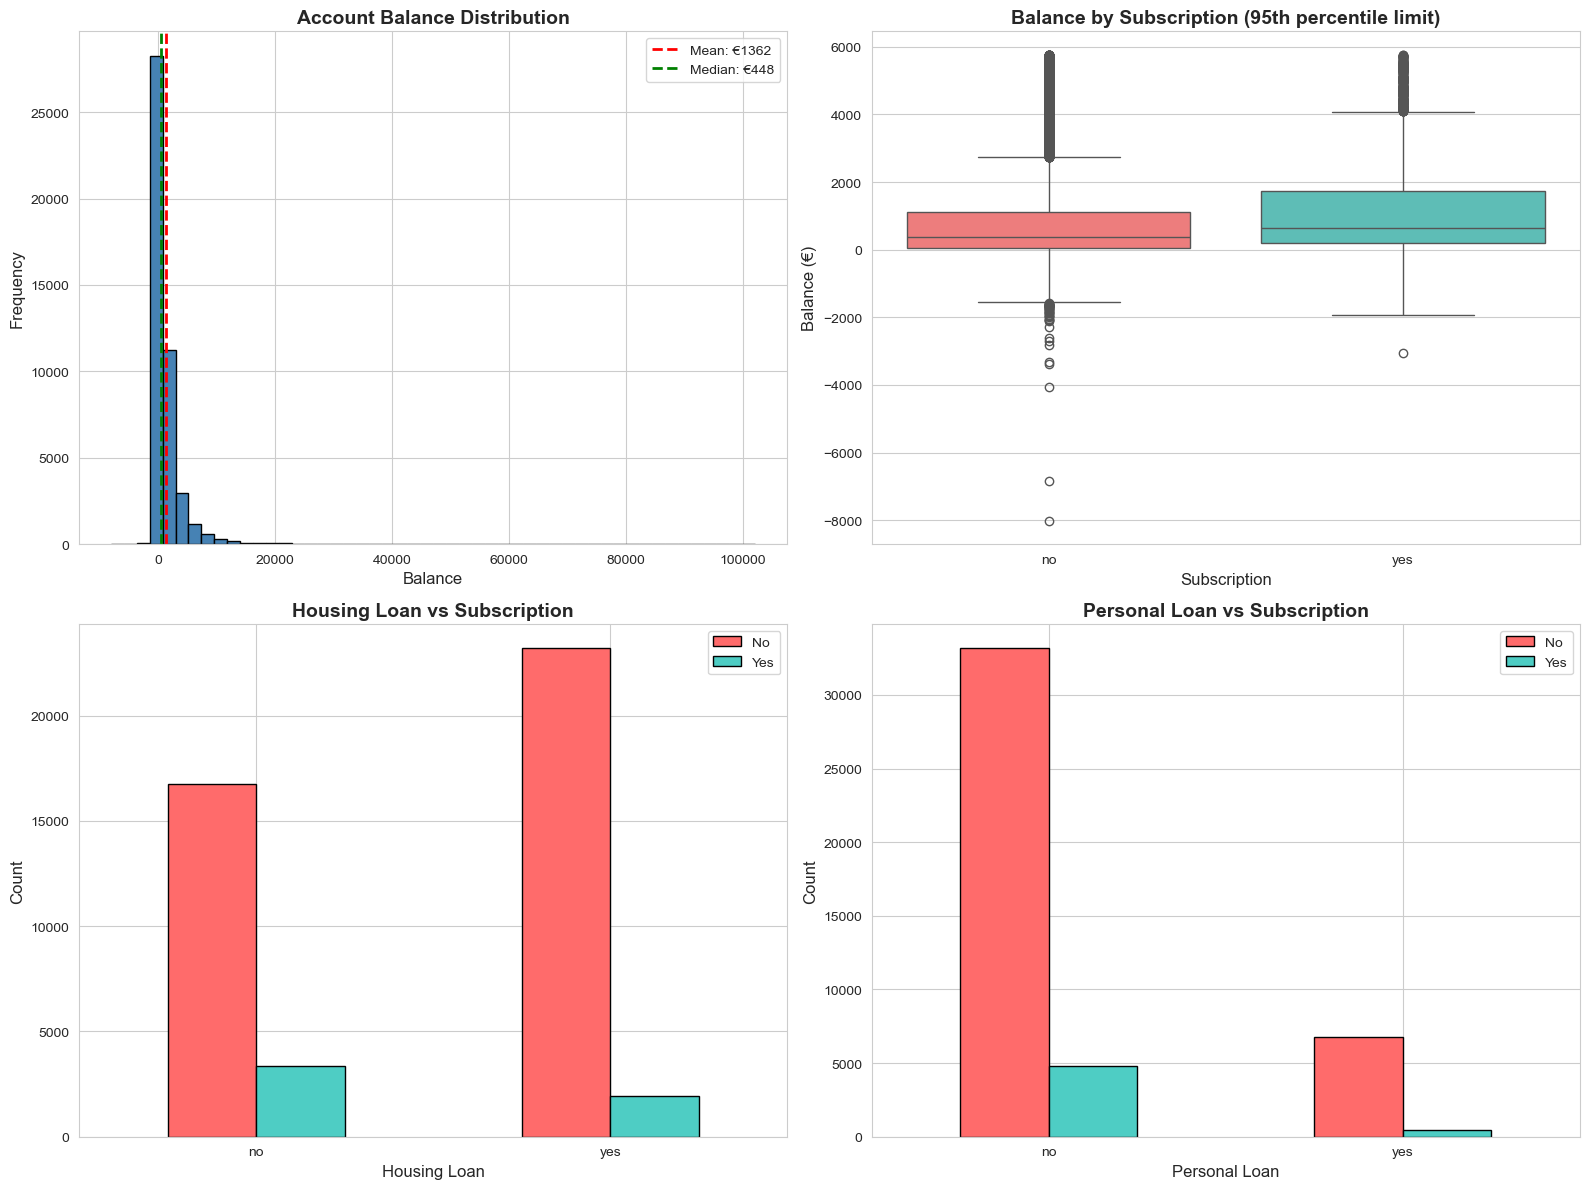

Balance Statistics by Subscription:
       count         mean          std     min    25%    50%     75%       max
y                                                                             
no   39922.0  1303.714969  2974.195473 -8019.0   58.0  417.0  1345.0  102127.0
yes   5289.0  1804.267915  3501.104777 -3058.0  210.0  733.0  2159.0   81204.0


In [14]:
# Balance analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Balance distribution (with outlier limit for visualization)
df['balance'].hist(bins=50, edgecolor='black', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Account Balance Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Balance', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].axvline(df['balance'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: €{df["balance"].mean():.0f}')
axes[0, 0].axvline(df['balance'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: €{df["balance"].median():.0f}')
axes[0, 0].legend()

# Balance box plot (limited range for better visualization)
balance_limit = df['balance'].quantile(0.95)
df_balance_limited = df[df['balance'] <= balance_limit]
sns.boxplot(x='y', y='balance', data=df_balance_limited, palette=['#FF6B6B', '#4ECDC4'], ax=axes[0, 1])
axes[0, 1].set_title('Balance by Subscription (95th percentile limit)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Subscription', fontsize=12)
axes[0, 1].set_ylabel('Balance (€)', fontsize=12)

# Housing loan analysis
housing_sub = pd.crosstab(df['housing'], df['y'])
housing_sub.plot(kind='bar', ax=axes[1, 0], color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[1, 0].set_title('Housing Loan vs Subscription', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Housing Loan', fontsize=12)
axes[1, 0].set_ylabel('Count', fontsize=12)
axes[1, 0].legend(['No', 'Yes'])
axes[1, 0].tick_params(axis='x', rotation=0)

# Personal loan analysis
loan_sub = pd.crosstab(df['loan'], df['y'])
loan_sub.plot(kind='bar', ax=axes[1, 1], color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[1, 1].set_title('Personal Loan vs Subscription', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Personal Loan', fontsize=12)
axes[1, 1].set_ylabel('Count', fontsize=12)
axes[1, 1].legend(['No', 'Yes'])
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("Balance Statistics by Subscription:")
print("="*50)
print(df.groupby('y')['balance'].describe())

### 5.4 Campaign Features Analysis - **CRITICAL for Business Insights**

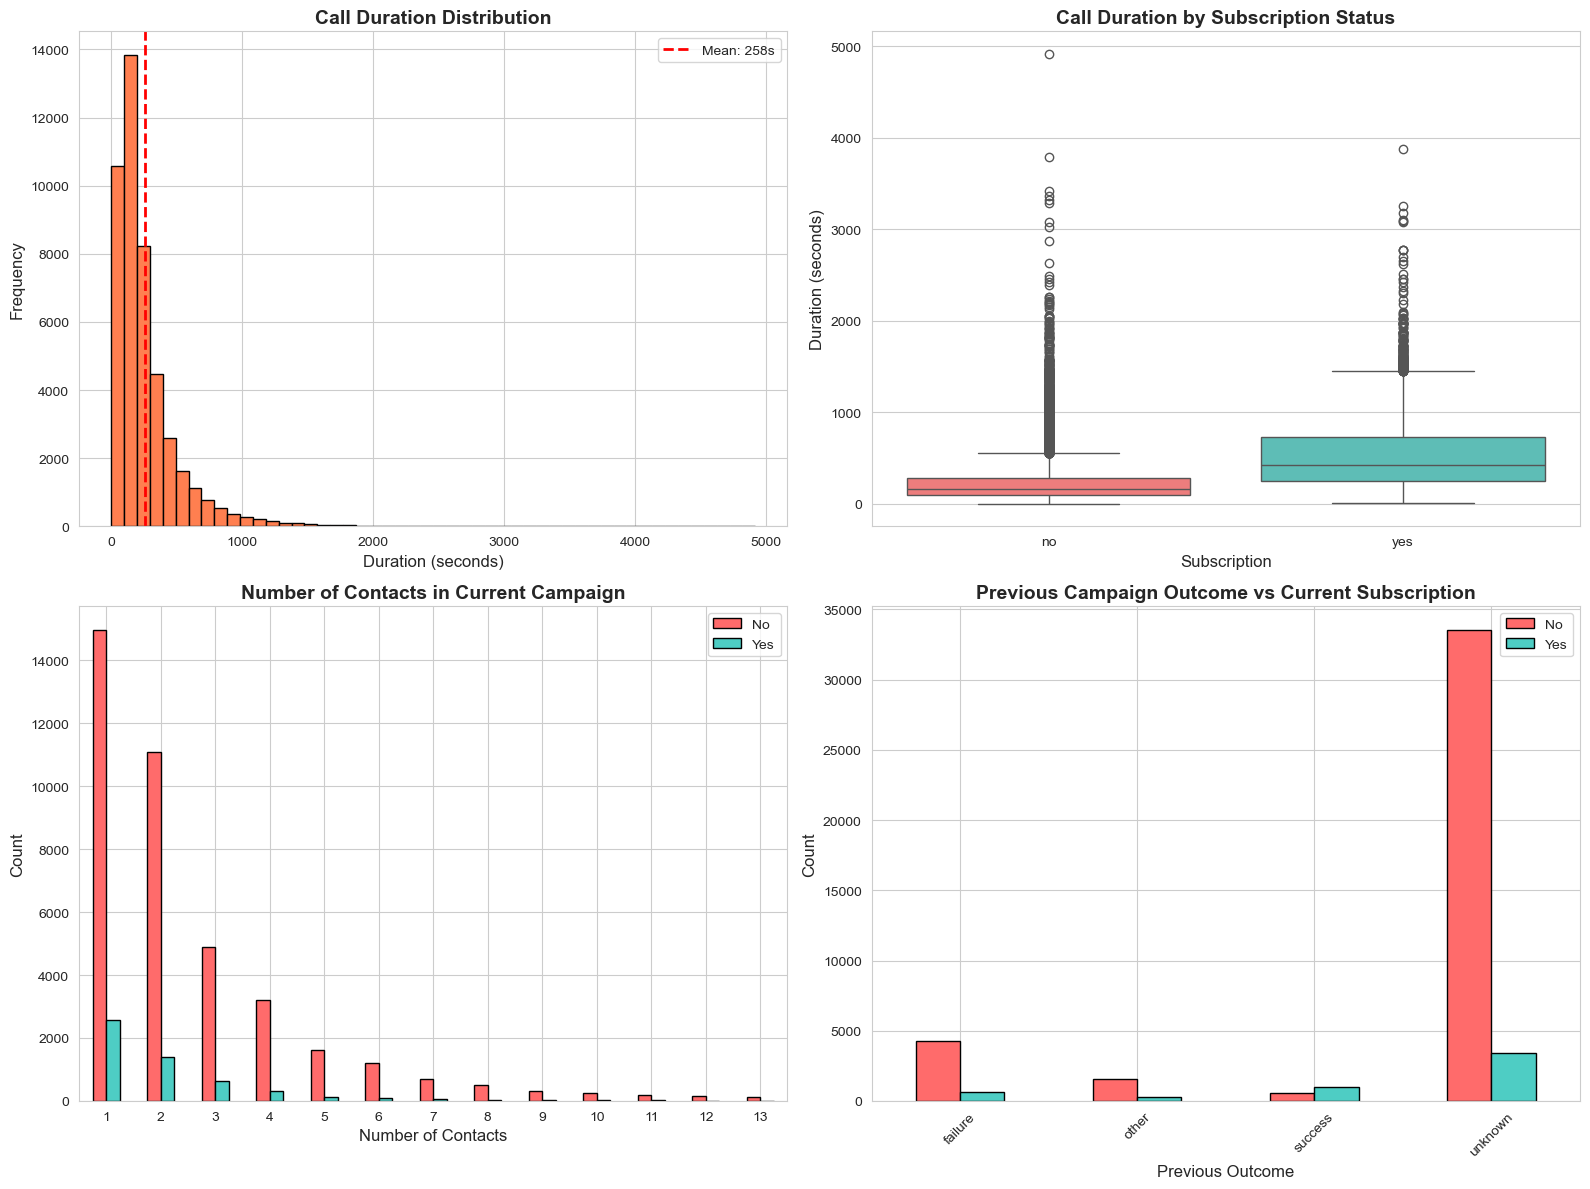

Duration Statistics by Subscription:
       count        mean         std  min    25%    50%    75%     max
y                                                                     
no   39922.0  221.182806  207.383237  0.0   95.0  164.0  279.0  4918.0
yes   5289.0  537.294574  392.525262  8.0  244.0  426.0  725.0  3881.0
   - Average duration for 'yes': 537 seconds
   - Average duration for 'no': 221 seconds
   - Difference: 316 seconds


In [15]:
# Duration analysis - MOST IMPORTANT FEATURE
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Duration distribution
df['duration'].hist(bins=50, edgecolor='black', ax=axes[0, 0], color='coral')
axes[0, 0].set_title('Call Duration Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Duration (seconds)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].axvline(df['duration'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["duration"].mean():.0f}s')
axes[0, 0].legend()

# Duration by subscription
sns.boxplot(x='y', y='duration', data=df, palette=['#FF6B6B', '#4ECDC4'], ax=axes[0, 1])
axes[0, 1].set_title('Call Duration by Subscription Status', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Subscription', fontsize=12)
axes[0, 1].set_ylabel('Duration (seconds)', fontsize=12)

# Campaign contacts
campaign_sub = df.groupby(['campaign', 'y']).size().unstack(fill_value=0)
campaign_sub[campaign_sub.sum(axis=1) > 100].plot(kind='bar', ax=axes[1, 0], color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[1, 0].set_title('Number of Contacts in Current Campaign', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Number of Contacts', fontsize=12)
axes[1, 0].set_ylabel('Count', fontsize=12)
axes[1, 0].legend(['No', 'Yes'])
axes[1, 0].tick_params(axis='x', rotation=0)

# Previous outcome
poutcome_sub = pd.crosstab(df['poutcome'], df['y'])
poutcome_sub.plot(kind='bar', ax=axes[1, 1], color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[1, 1].set_title('Previous Campaign Outcome vs Current Subscription', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Previous Outcome', fontsize=12)
axes[1, 1].set_ylabel('Count', fontsize=12)
axes[1, 1].legend(['No', 'Yes'])
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Duration Statistics by Subscription:")
print("="*50)
print(df.groupby('y')['duration'].describe())

print(f"   - Average duration for 'yes': {df[df['y']=='yes']['duration'].mean():.0f} seconds")
print(f"   - Average duration for 'no': {df[df['y']=='no']['duration'].mean():.0f} seconds")
print(f"   - Difference: {df[df['y']=='yes']['duration'].mean() - df[df['y']=='no']['duration'].mean():.0f} seconds")

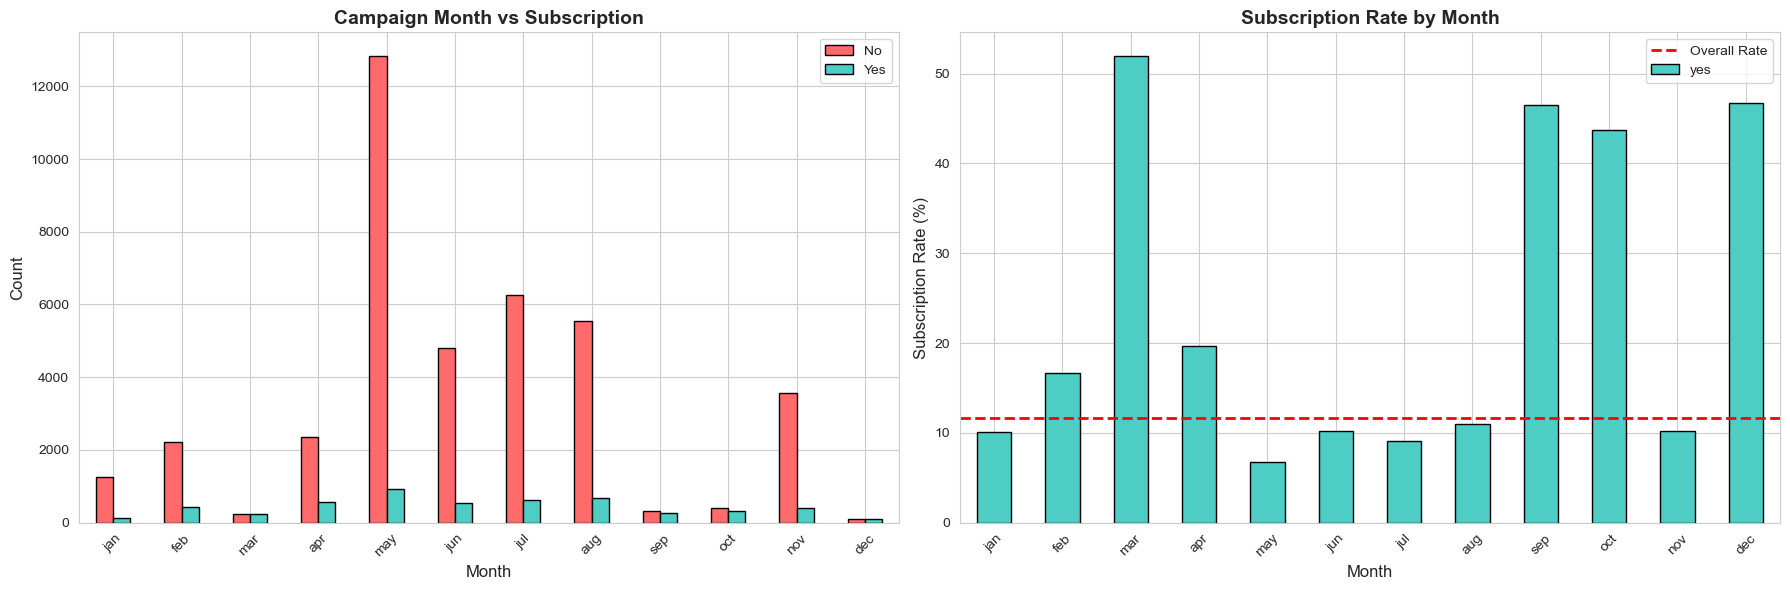

Subscription Rate by Month:
month
mar    51.991614
dec    46.728972
sep    46.459413
oct    43.766938
apr    19.679400
feb    16.647792
aug    11.013286
jun    10.222805
nov    10.151134
jan    10.121169
jul     9.093546
may     6.719454
Name: yes, dtype: float64
March, September, October, and December show higher subscription rates!


In [16]:
# Month and Day analysis
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Month analysis
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_sub = pd.crosstab(df['month'], df['y'])
month_sub = month_sub.reindex([m for m in month_order if m in month_sub.index])
month_sub.plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[0].set_title('Campaign Month vs Subscription', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].legend(['No', 'Yes'])
axes[0].tick_params(axis='x', rotation=45)

# Subscription rate by month
month_rate = pd.crosstab(df['month'], df['y'], normalize='index') * 100
month_rate = month_rate.reindex([m for m in month_order if m in month_rate.index])
month_rate['yes'].plot(kind='bar', ax=axes[1], color='#4ECDC4', edgecolor='black')
axes[1].set_title('Subscription Rate by Month', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month', fontsize=12)
axes[1].set_ylabel('Subscription Rate (%)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=11.7, color='red', linestyle='--', linewidth=2, label='Overall Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Subscription Rate by Month:")

print(month_rate['yes'].sort_values(ascending=False))

print("March, September, October, and December show higher subscription rates!")

### 5.5 Correlation Analysis

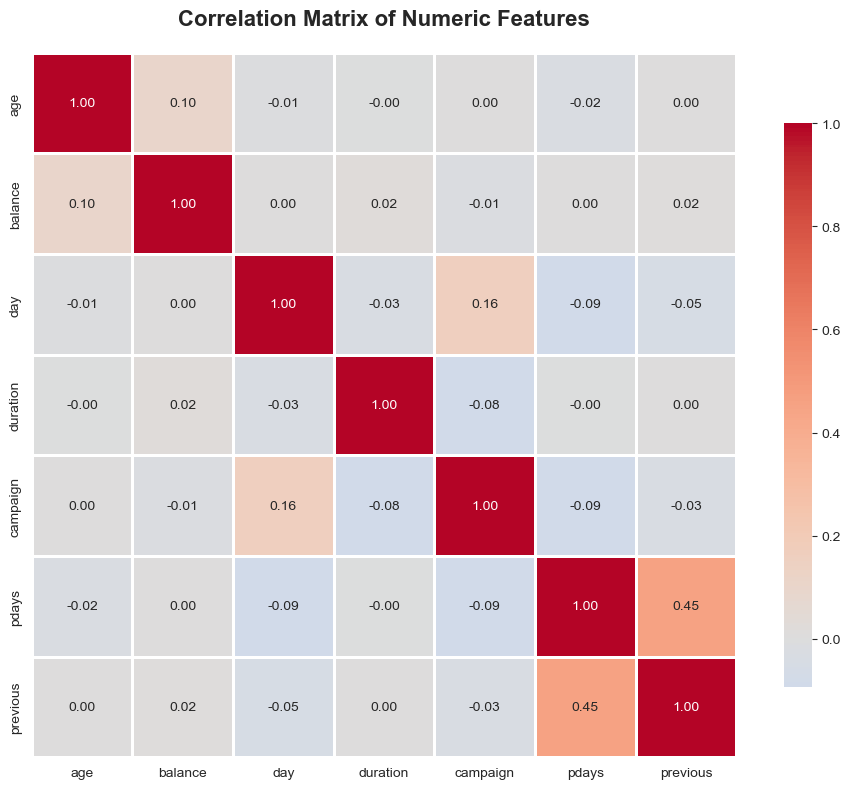

from Correlation:
   - pdays and previous are positively correlated (customers contacted before)
   - Most features show low correlation with each other (good for modeling)


In [17]:
# Correlation matrix for numeric features
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numeric Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("from Correlation:")
print("   - pdays and previous are positively correlated (customers contacted before)")
print("   - Most features show low correlation with each other (good for modeling)")

## 6. Data Preprocessing & Feature Engineering

In [18]:
# Create a copy for preprocessing
df_processed = df.copy()

In [19]:
# Feature Engineering - Create new features

# Age groups
df_processed['age_group'] = pd.cut(df_processed['age'], 
                                    bins=[0, 30, 40, 50, 60, 100], 
                                    labels=['<30', '30-40', '40-50', '50-60', '60+'])

# Balance categories
df_processed['balance_category'] = pd.cut(df_processed['balance'],
                                           bins=[-np.inf, 0, 1000, 5000, np.inf],
                                           labels=['negative', 'low', 'medium', 'high'])

# Duration categories (in minutes)
df_processed['duration_minutes'] = df_processed['duration'] / 60
df_processed['duration_category'] = pd.cut(df_processed['duration'],
                                            bins=[0, 180, 300, 600, np.inf],
                                            labels=['short', 'medium', 'long', 'very_long'])

# Campaign intensity
df_processed['campaign_intensity'] = df_processed['campaign'].apply(
    lambda x: 'low' if x <= 2 else ('medium' if x <= 5 else 'high')
)

# Contact history
df_processed['was_contacted_before'] = (df_processed['pdays'] != -1).astype(int)

# Previous success
df_processed['previous_success'] = (df_processed['poutcome'] == 'success').astype(int)

In [20]:
# Encode target variable
df_processed['y'] = df_processed['y'].map({'yes': 1, 'no': 0})

In [21]:
# One-hot encoding for categorical variables

# Select categorical columns to encode
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 
                    'contact', 'month', 'poutcome', 'age_group', 'balance_category', 
                    'duration_category', 'campaign_intensity']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

print(f"Categorical variables encoded")
print(f"   Original features: {df_processed.shape[1]}")
print(f"   After encoding: {df_encoded.shape[1]}")

Categorical variables encoded
   Original features: 24
   After encoding: 58


In [22]:
# Prepare features and target
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nClass ratio: {y.value_counts()[0]/y.value_counts()[1]:.2f}:1")

Feature matrix shape: (45211, 57)
Target vector shape: (45211,)

Target distribution:
y
0    39922
1     5289
Name: count, dtype: int64

Class ratio: 7.55:1


## 7. Train-Test Split with Stratification

In [23]:
# Split data with STRATIFICATION (important for imbalanced data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # CRITICAL: Maintains class distribution in both sets
)

print(f"\nTraining set size: {X_train.shape[0]:,} samples")
print(f"Test set size: {X_test.shape[0]:,} samples")

print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"Percentage: {y_train.value_counts(normalize=True) * 100}")

print(f"\nTest set class distribution:")
print(y_test.value_counts())
print(f"Percentage: {y_test.value_counts(normalize=True) * 100}")


Training set size: 36,168 samples
Test set size: 9,043 samples

Training set class distribution:
y
0    31937
1     4231
Name: count, dtype: int64
Percentage: y
0    88.301814
1    11.698186
Name: proportion, dtype: float64

Test set class distribution:
y
0    7985
1    1058
Name: count, dtype: int64
Percentage: y
0    88.300343
1    11.699657
Name: proportion, dtype: float64


## 8. Feature Scaling

In [24]:
# Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler")
print(f"   Mean: ~0, Std: ~1")

# Convert back to DataFrame for better readability
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

Features scaled using StandardScaler
   Mean: ~0, Std: ~1


## 9. Handling Class Imbalance with SMOTE

In [25]:
# Apply SMOTE to training data only
print("\nBefore SMOTE:")
print(f"Class 0 (no): {sum(y_train == 0):,}")
print(f"Class 1 (yes): {sum(y_train == 1):,}")
print(f"Ratio: {sum(y_train == 0)/sum(y_train == 1):.2f}:1")

# Apply SMOTE
smote = SMOTE(random_state=42, sampling_strategy=0.8)  # 80% of majority class
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE:")
print(f"Class 0 (no): {sum(y_train_smote == 0):,}")
print(f"Class 1 (yes): {sum(y_train_smote == 1):,}")
print(f"Ratio: {sum(y_train_smote == 0)/sum(y_train_smote == 1):.2f}:1")

print("\nSMOTE applied successfully!")
print("   This creates synthetic samples of the minority class")
print("   helping models learn better patterns for 'yes' subscriptions")


Before SMOTE:
Class 0 (no): 31,937
Class 1 (yes): 4,231
Ratio: 7.55:1

After SMOTE:
Class 0 (no): 31,937
Class 1 (yes): 25,549
Ratio: 1.25:1

SMOTE applied successfully!
   This creates synthetic samples of the minority class
   helping models learn better patterns for 'yes' subscriptions


## 10. Model Building & Evaluation

We'll build and compare multiple models:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting

### 10.1 Logistic Regression

In [26]:
# Train with SMOTE data
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['No', 'Yes']))

print("\nConfusion Matrix:")
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

Accuracy: 0.8565
Precision: 0.4364
Recall: 0.7788
F1-Score: 0.5594
ROC-AUC: 0.9074

Classification Report:
              precision    recall  f1-score   support

          No       0.97      0.87      0.91      7985
         Yes       0.44      0.78      0.56      1058

    accuracy                           0.86      9043
   macro avg       0.70      0.82      0.74      9043
weighted avg       0.91      0.86      0.87      9043


Confusion Matrix:
[[6921 1064]
 [ 234  824]]


### 10.2 Decision Tree

In [27]:
# Train with SMOTE data
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_split=100)
dt_model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_dt = dt_model.predict(X_test_scaled)
y_pred_proba_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_dt):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['No', 'Yes']))

print("\nConfusion Matrix:")
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

Accuracy: 0.8604
Precision: 0.4381
Recall: 0.6824
F1-Score: 0.5336
ROC-AUC: 0.8845

Classification Report:
              precision    recall  f1-score   support

          No       0.95      0.88      0.92      7985
         Yes       0.44      0.68      0.53      1058

    accuracy                           0.86      9043
   macro avg       0.70      0.78      0.73      9043
weighted avg       0.89      0.86      0.87      9043


Confusion Matrix:
[[7059  926]
 [ 336  722]]


### 10.3 Random Forest

In [28]:
# Train with SMOTE data
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15, min_samples_split=50)
rf_model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No', 'Yes']))

print("\nConfusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

Accuracy: 0.8840
Precision: 0.5032
Recall: 0.6739
F1-Score: 0.5762
ROC-AUC: 0.9194

Classification Report:
              precision    recall  f1-score   support

          No       0.95      0.91      0.93      7985
         Yes       0.50      0.67      0.58      1058

    accuracy                           0.88      9043
   macro avg       0.73      0.79      0.75      9043
weighted avg       0.90      0.88      0.89      9043


Confusion Matrix:
[[7281  704]
 [ 345  713]]


### 10.4 Gradient Boosting

In [29]:
# Train with SMOTE data
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5, learning_rate=0.1)
gb_model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_gb = gb_model.predict(X_test_scaled)
y_pred_proba_gb = gb_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_gb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_gb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_gb):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb, target_names=['No', 'Yes']))

print("\nConfusion Matrix:")
cm_gb = confusion_matrix(y_test, y_pred_gb)
print(cm_gb)

Accuracy: 0.9035
Precision: 0.5859
Recall: 0.5964
F1-Score: 0.5911
ROC-AUC: 0.9263

Classification Report:
              precision    recall  f1-score   support

          No       0.95      0.94      0.95      7985
         Yes       0.59      0.60      0.59      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.77      0.77      9043
weighted avg       0.90      0.90      0.90      9043


Confusion Matrix:
[[7539  446]
 [ 427  631]]


## 11. Model Comparison

In [30]:
# Create comparison dataframe
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba_lr),
        roc_auc_score(y_test, y_pred_proba_dt),
        roc_auc_score(y_test, y_pred_proba_rf),
        roc_auc_score(y_test, y_pred_proba_gb)
    ]
})

print("\n" + "="*80)
print("MODEL COMPARISON TABLE")
print("="*80)
print(model_comparison.to_string(index=False))
print("="*80)

# Find best model
best_model_idx = model_comparison['F1-Score'].idxmax()
best_model_name = model_comparison.loc[best_model_idx, 'Model']
best_f1 = model_comparison.loc[best_model_idx, 'F1-Score']

print(f"\nBEST MODEL: {best_model_name}")
print(f"   F1-Score: {best_f1:.4f}")
print(f"   ROC-AUC: {model_comparison.loc[best_model_idx, 'ROC-AUC']:.4f}")


MODEL COMPARISON TABLE
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.856464   0.436441 0.778828  0.559403 0.907438
      Decision Tree  0.860445   0.438107 0.682420  0.533629 0.884530
      Random Forest  0.883999   0.503176 0.673913  0.576162 0.919414
  Gradient Boosting  0.903461   0.585887 0.596408  0.591101 0.926286

BEST MODEL: Gradient Boosting
   F1-Score: 0.5911
   ROC-AUC: 0.9263


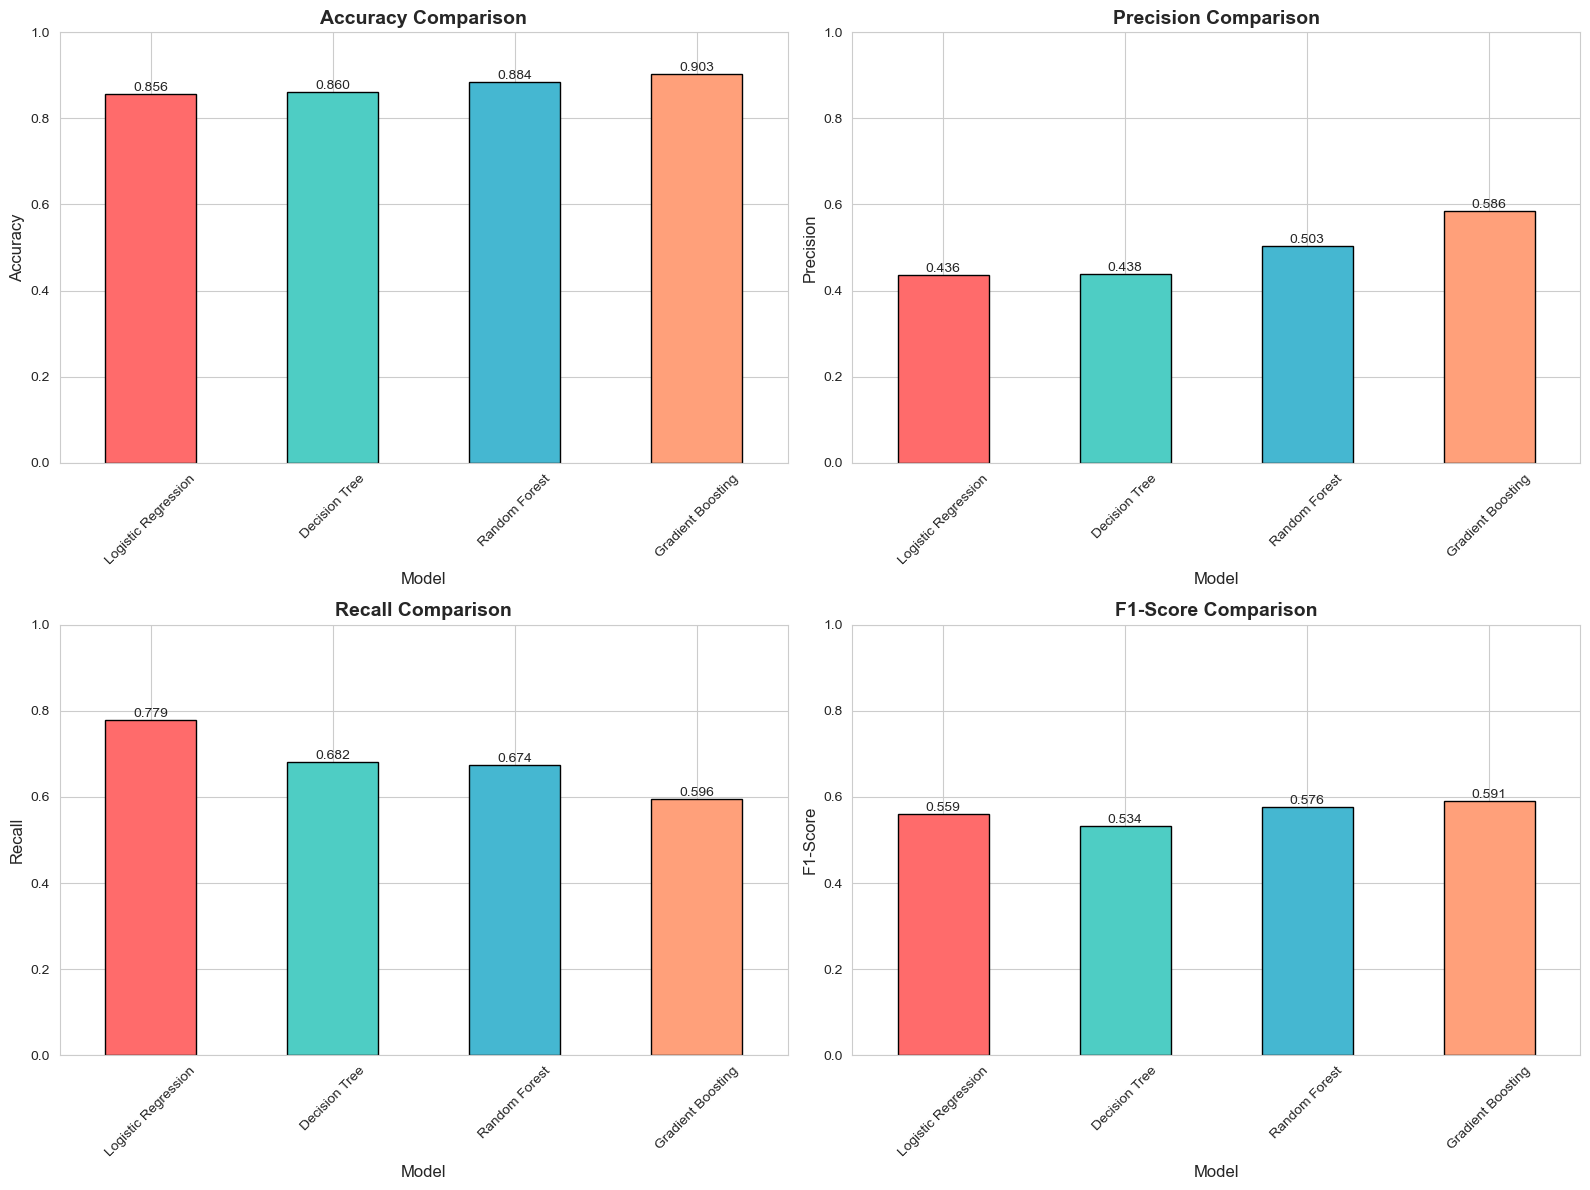

In [31]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for idx, (ax, metric) in enumerate(zip(axes.flat, metrics)):
    model_comparison.plot(x='Model', y=metric, kind='bar', ax=ax, 
                          color=colors, legend=False, edgecolor='black')
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim([0, 1])
    
    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=10)

plt.tight_layout()
plt.show()

## 12. Confusion Matrix Visualization

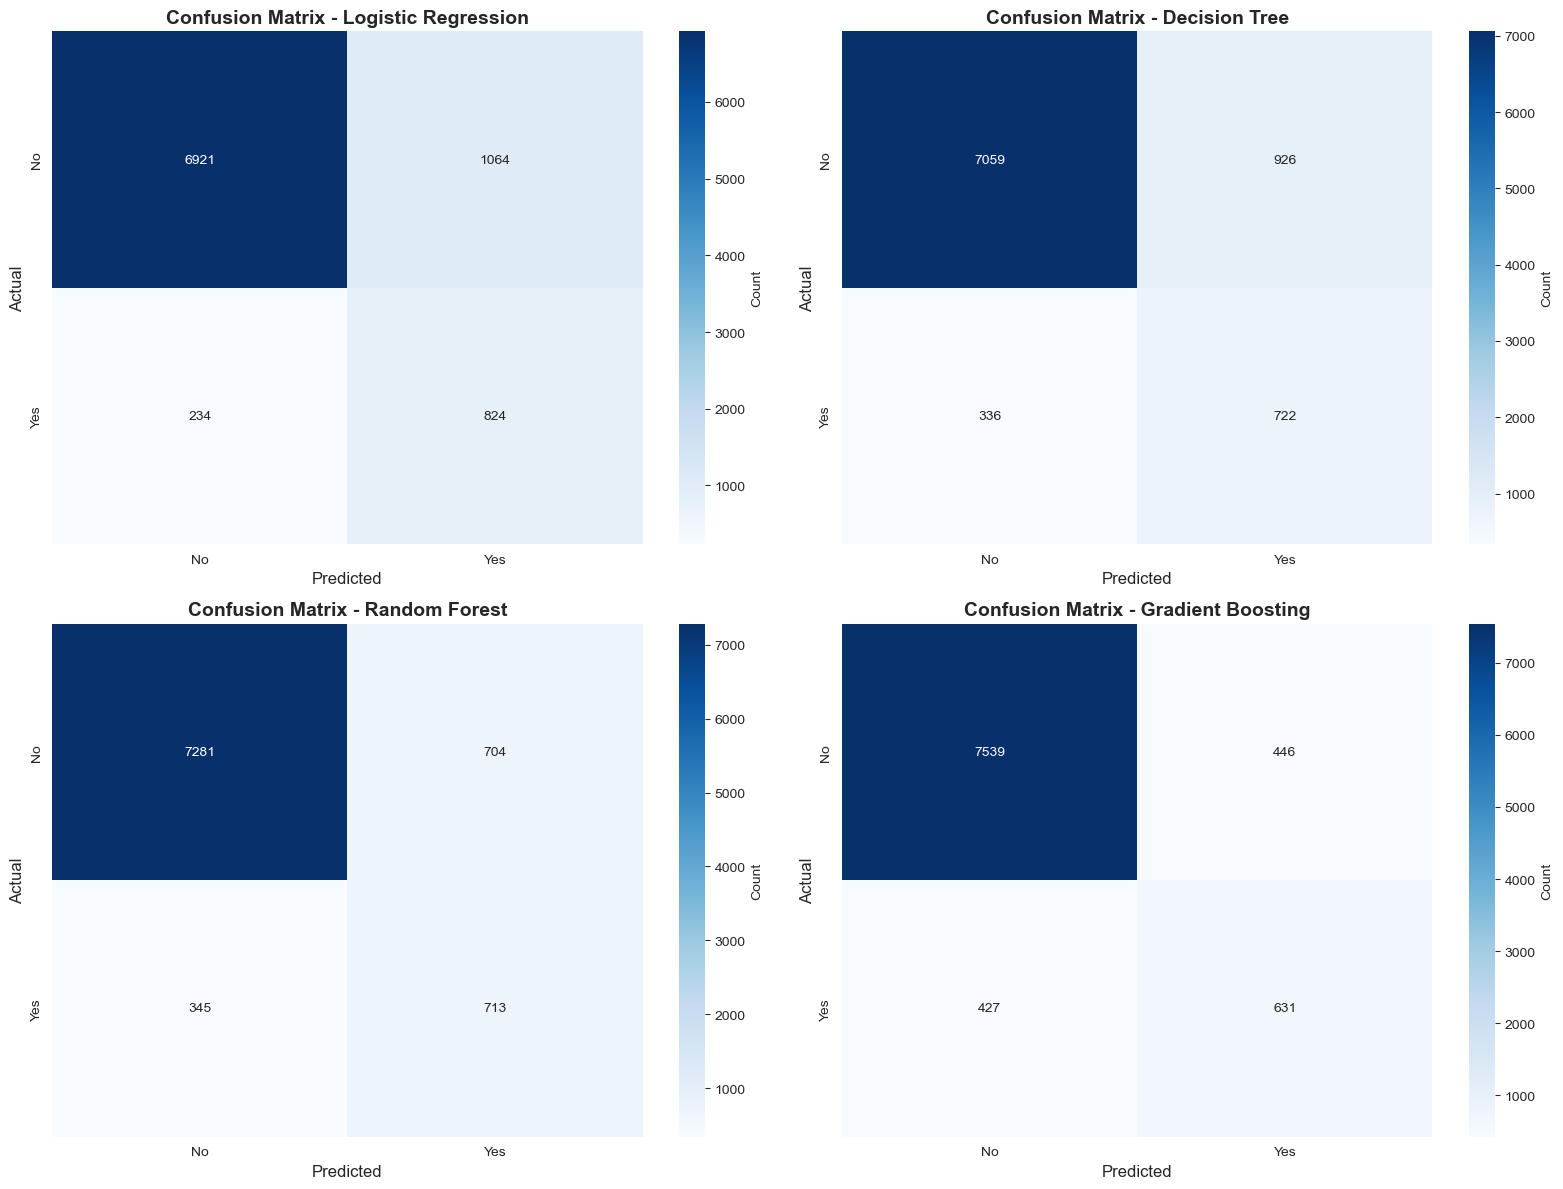

In [32]:
# Visualize confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

confusion_matrices = [
    (cm_lr, 'Logistic Regression'),
    (cm_dt, 'Decision Tree'),
    (cm_rf, 'Random Forest'),
    (cm_gb, 'Gradient Boosting')
]

for ax, (cm, title) in zip(axes.flat, confusion_matrices):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
                cbar_kws={'label': 'Count'})
    ax.set_title(f'Confusion Matrix - {title}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)

plt.tight_layout()
plt.show()

## 13. ROC Curves

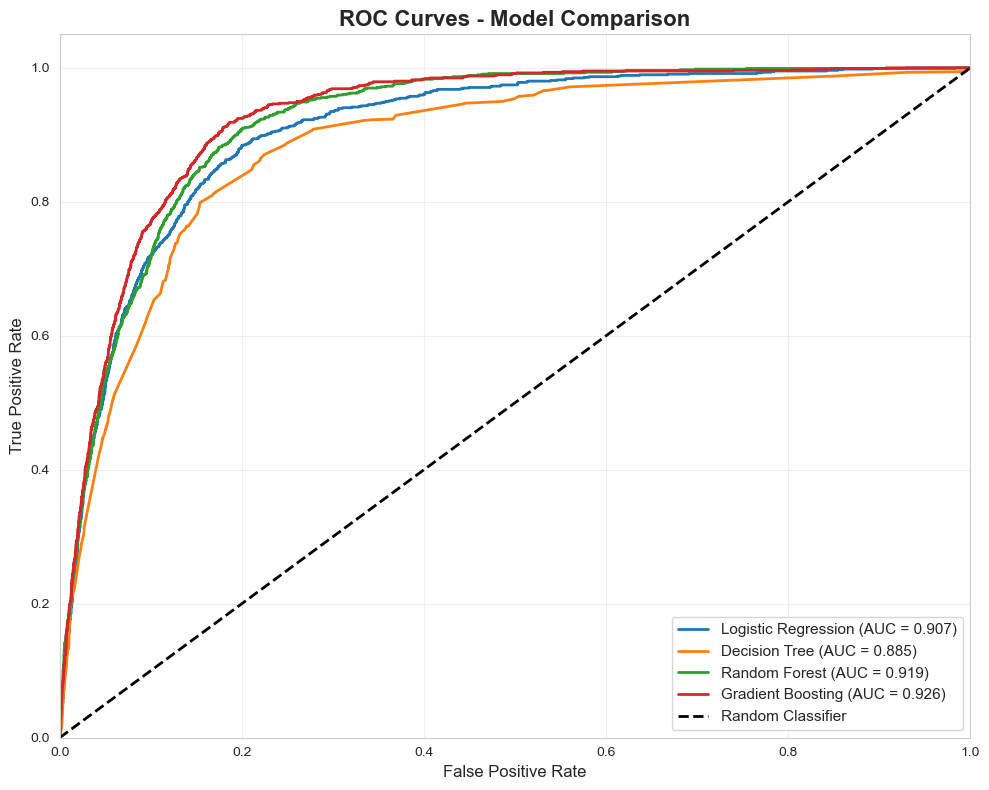


INTERPRETATION:
   - Curves closer to top-left corner indicate better performance
   - AUC closer to 1.0 indicates better model discrimination
   - All models perform significantly better than random (0.5)


In [33]:
# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

models_roc = [
    ('Logistic Regression', y_pred_proba_lr),
    ('Decision Tree', y_pred_proba_dt),
    ('Random Forest', y_pred_proba_rf),
    ('Gradient Boosting', y_pred_proba_gb)
]

for name, y_proba in models_roc:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Plot diagonal line
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nINTERPRETATION:")
print("   - Curves closer to top-left corner indicate better performance")
print("   - AUC closer to 1.0 indicates better model discrimination")
print("   - All models perform significantly better than random (0.5)")

## 14. Precision-Recall Curves

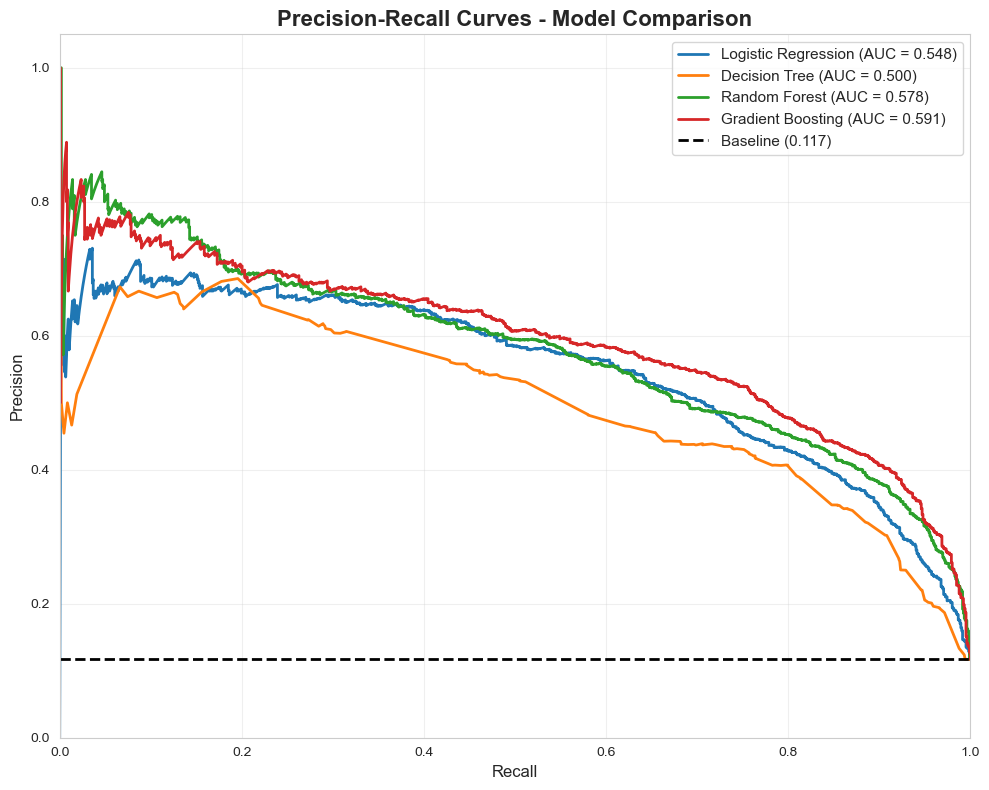


INTERPRETATION:
   - Precision-Recall curves are especially useful for imbalanced datasets
   - Higher area under curve indicates better trade-off between precision and recall
   - Important for business: High recall means we identify more potential subscribers


In [34]:
# Plot Precision-Recall curves
plt.figure(figsize=(10, 8))

for name, y_proba in models_roc:
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, linewidth=2, label=f'{name} (AUC = {pr_auc:.3f})')

# Baseline
baseline = sum(y_test) / len(y_test)
plt.axhline(y=baseline, color='k', linestyle='--', linewidth=2, label=f'Baseline ({baseline:.3f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves - Model Comparison', fontsize=16, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nINTERPRETATION:")
print("   - Precision-Recall curves are especially useful for imbalanced datasets")
print("   - Higher area under curve indicates better trade-off between precision and recall")
print("   - Important for business: High recall means we identify more potential subscribers")

## 15. Feature Importance Analysis

In [35]:
# Feature importance from Random Forest
# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(20))

                        Feature  Importance
3                      duration    0.154626
7              duration_minutes    0.152936
27                  housing_yes    0.085540
54  duration_category_very_long    0.079027
4                      campaign    0.050601
30              contact_unknown    0.043407
43             poutcome_success    0.034722
53       duration_category_long    0.033307
52     duration_category_medium    0.028254
9              previous_success    0.027830
1                       balance    0.025150
38                    month_may    0.021339
0                           age    0.016714
28                     loan_yes    0.015822
21              marital_married    0.015542
6                      previous    0.014221
8          was_contacted_before    0.013073
5                         pdays    0.012978
2                           day    0.012202
44             poutcome_unknown    0.011768


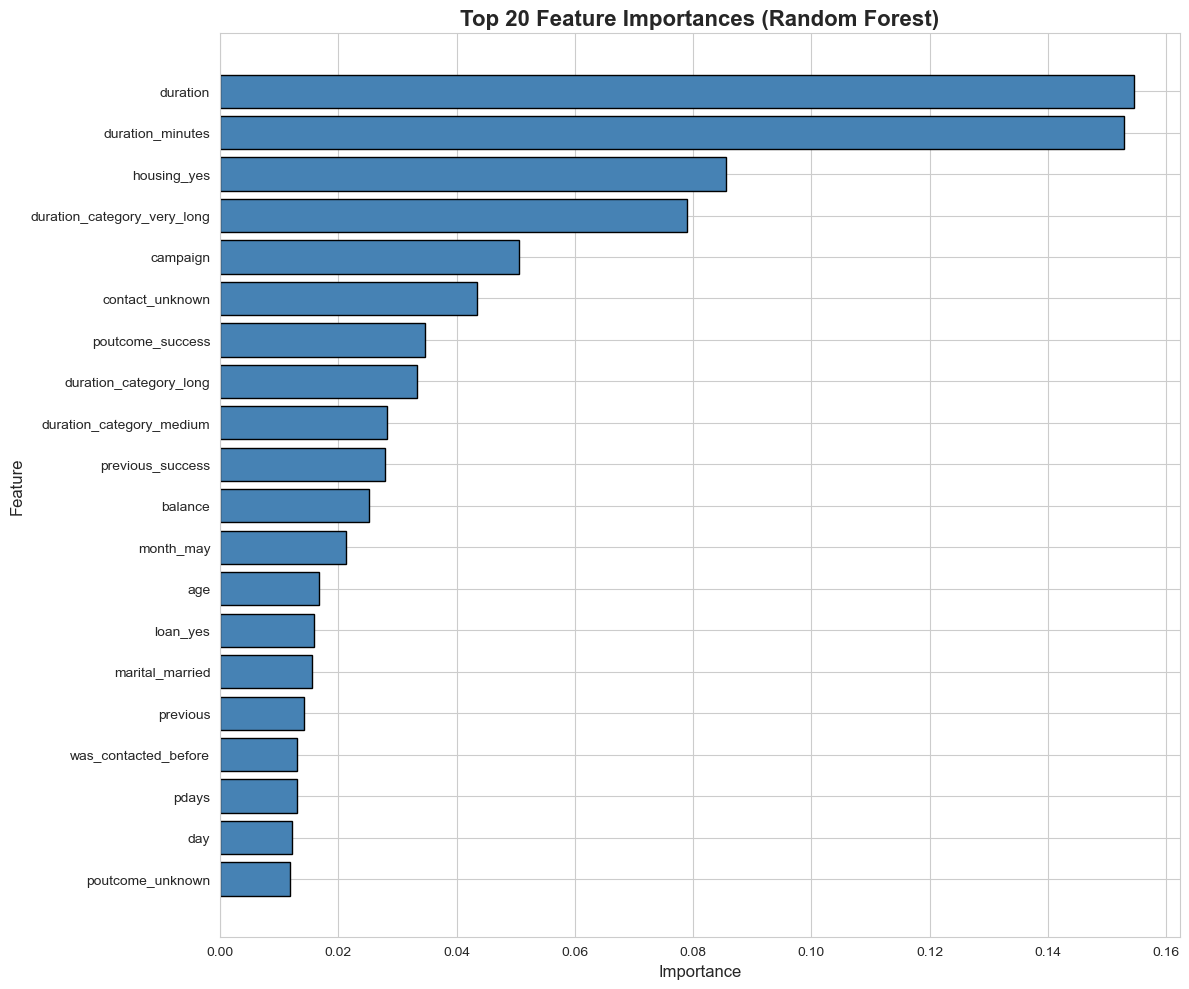

   - Duration is the MOST important feature (as expected)
   - Previous campaign outcomes significantly impact subscription
   - Contact month and demographic factors also play important roles


In [36]:
# Visualize top 20 features
plt.figure(figsize=(12, 10))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue', edgecolor='black')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 20 Feature Importances (Random Forest)', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("   - Duration is the MOST important feature (as expected)")
print("   - Previous campaign outcomes significantly impact subscription")
print("   - Contact month and demographic factors also play important roles")

## 16. Hyperparameter Tuning (Optional - Random Forest)

In [37]:
# Hyperparameter tuning for Random Forest using GridSearchCV
# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 20],
    'min_samples_split': [50, 100, 150],
    'min_samples_leaf': [20, 30, 40]
}

# Create GridSearchCV
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Fit grid search
grid_search.fit(X_train_smote, y_train_smote)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best F1-Score (CV): {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 81 candidates, totalling 243 fits

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 20, 'min_samples_split': 50, 'n_estimators': 150}
Best F1-Score (CV): 0.8971


In [38]:
# Evaluate tuned model
rf_tuned = grid_search.best_estimator_
y_pred_rf_tuned = rf_tuned.predict(X_test_scaled)
y_pred_proba_rf_tuned = rf_tuned.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf_tuned):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf_tuned):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf_tuned):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_tuned, target_names=['No', 'Yes']))

# Compare with original
print("\nImprovement from Tuning:")
print(f"F1-Score Improvement: {f1_score(y_test, y_pred_rf_tuned) - f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC Improvement: {roc_auc_score(y_test, y_pred_proba_rf_tuned) - roc_auc_score(y_test, y_pred_proba_rf):.4f}")

Accuracy: 0.8838
Precision: 0.5025
Recall: 0.6739
F1-Score: 0.5757
ROC-AUC: 0.9162

Classification Report:
              precision    recall  f1-score   support

          No       0.95      0.91      0.93      7985
         Yes       0.50      0.67      0.58      1058

    accuracy                           0.88      9043
   macro avg       0.73      0.79      0.75      9043
weighted avg       0.90      0.88      0.89      9043


Improvement from Tuning:
F1-Score Improvement: -0.0005
ROC-AUC Improvement: -0.0032
